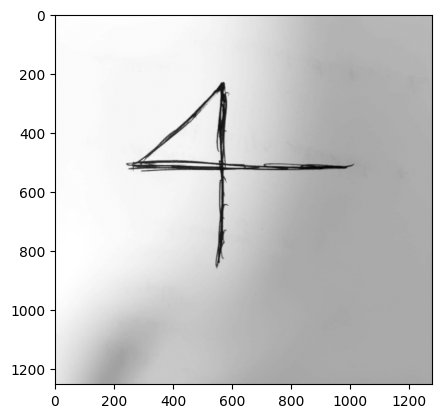

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/content/drive/MyDrive/AI/WhatsApp Image 2026-06-04 at 10.35.13 AM.jpeg", cv2.IMREAD_GRAYSCALE)

img_inv = 255 - img

coords = cv2.findNonZero(img_inv)

x, y, w, h = cv2.boundingRect(coords)

digit = img[y:y+h, x:x+w]

plt.imshow(digit, cmap='gray')
plt.show()

In [ ]:
digit = cv2.resize(digit, (28,28))
digit = 255 - digit
digit = digit / 255.0

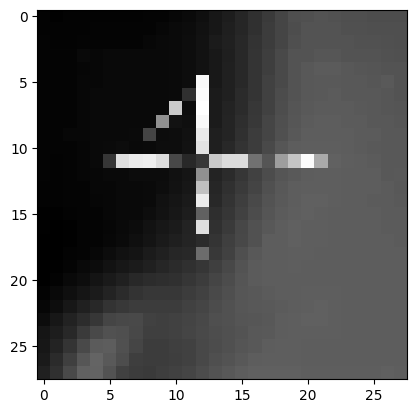

In [ ]:
plt.imshow(digit, cmap='gray')
plt.show()

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


digit_input = digit.reshape(1,28,28,1)
pred = model.predict(digit_input)
print("Predicted:", np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted: 4


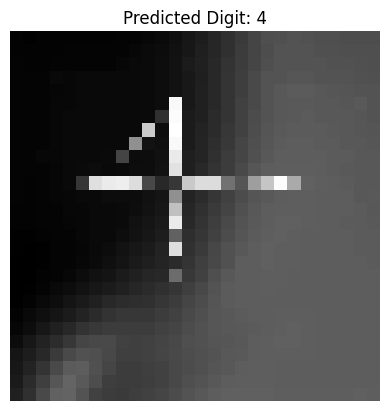

In [ ]:
plt.imshow(digit.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {np.argmax(pred)}")
plt.axis('off')
plt.show()

In [ ]:
model.save('mnist_model..h5')